In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from datasets import load_dataset
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
from PIL import Image
import wandb

c:\Users\mayan\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [42]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [43]:
# Set random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

# Configuration
class Config:
    # Dataset parameters
    dataset_name = "timm/mini-imagenet"
    img_size = 84  # Mini-ImageNet images are 84x84
    n_channels = 3
    
    # Few-shot learning setup
    n_ways = 5  # Number of classes in each task
    n_shots = 5  # Number of examples per class for training (k-shot)
    n_query = 15  # Number of examples per class for testing
    
    # GAN parameters
    latent_dim = 100
    g_hidden_dim = 64
    d_hidden_dim = 64
    gan_epochs = 100
    gan_batch_size = 16
    gan_lr = 0.0002
    gan_beta1 = 0.5
    n_synthetic_per_class = 20  # Number of synthetic images to generate per class
    
    # ViT parameters
    vit_patch_size = 4
    vit_dim = 192
    vit_depth = 6
    vit_heads = 8
    vit_mlp_dim = 768
    vit_dropout = 0.1
    
    # Training parameters
    vit_epochs = 50
    vit_batch_size = 16
    vit_lr = 0.0001
    weight_decay = 1e-4
    
    # Experiment tracking
    use_wandb = False
    wandb_project = "few-shot-gan-augmentation"

# Initialize wandb (optional)
if Config.use_wandb:
    wandb.init(project=Config.wandb_project, config=vars(Config))

In [3]:
# Global cache for datasets
cached_data = {
    'train_dataset': None,
    'val_dataset': None,
    'test_dataset': None,
    'n_classes': None,
    'class_to_idx': None
}

In [45]:
#-------------------------------------------------------------------
# 1. Data Loading and Preprocessing
#-------------------------------------------------------------------

class MiniImageNetDataset(Dataset):
    def __init__(self, dataset_split, transform=None):
        self.dataset = dataset_split
        self.transform = transform
        
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        img = self.dataset[idx]['image']
        label = self.dataset[idx]['label']
        
        # Check image mode and convert to RGB if needed
        img_mode = getattr(img, 'mode', None)
        if img_mode is None:  # Handle tensors or arrays
            # If it's already a tensor with shape [H,W,C] where C=4, convert to C=3
            if isinstance(img, torch.Tensor) and img.shape[-1] == 4:
                img = img[..., :3]  # Keep only RGB channels
        else:
            # Convert any non-RGB PIL image to RGB
            if img_mode != 'RGB':
                img = img.convert('RGB')
            
        if self.transform:
            img = self.transform(img)
            
        return img, label

# Modified data loading function with caching
def load_mini_imagenet():
    # Check if data is already cached
    if cached_data['train_dataset'] is not None:
        print("Using cached datasets...")
        return (cached_data['train_dataset'], 
                cached_data['val_dataset'], 
                cached_data['test_dataset'], 
                cached_data['n_classes'], 
                cached_data['class_to_idx'])
    
    # Load dataset
    print("Loading and preprocessing data...")
    dataset = load_dataset(Config.dataset_name)
    
    # Define transforms
    train_transform = transforms.Compose([
        transforms.Resize((Config.img_size, Config.img_size)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    test_transform = transforms.Compose([
        transforms.Resize((Config.img_size, Config.img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # Create datasets
    train_dataset = MiniImageNetDataset(dataset['train'], transform=train_transform)
    val_dataset = MiniImageNetDataset(dataset['validation'], transform=test_transform)
    test_dataset = MiniImageNetDataset(dataset['test'], transform=test_transform)
    
    # Class information
    all_classes = sorted(list(set([item['label'] for item in dataset['train']])))
    n_classes = len(all_classes)
    class_to_idx = {cls: idx for idx, cls in enumerate(all_classes)}
    
    # Cache the datasets
    cached_data['train_dataset'] = train_dataset
    cached_data['val_dataset'] = val_dataset
    cached_data['test_dataset'] = test_dataset
    cached_data['n_classes'] = n_classes
    cached_data['class_to_idx'] = class_to_idx
    
    return train_dataset, val_dataset, test_dataset, n_classes, class_to_idx

In [46]:
#-------------------------------------------------------------------
# 2. Few-Shot Dataset Creation
#-------------------------------------------------------------------

class FewShotDataset:
    def __init__(self, dataset, n_ways, n_shots, n_query):
        self.dataset = dataset
        self.n_ways = n_ways  # Number of classes
        self.n_shots = n_shots  # Number of support examples per class
        self.n_query = n_query  # Number of query examples per class
        
        # Group samples by class
        self.samples_by_class = {}
        for idx in range(len(dataset)):
            _, label = dataset[idx]
            if label not in self.samples_by_class:
                self.samples_by_class[label] = []
            self.samples_by_class[label].append(idx)
            
        self.classes = list(self.samples_by_class.keys())
        
    def create_few_shot_task(self):
        # Randomly select n_ways classes
        selected_classes = random.sample(self.classes, self.n_ways)
        
        # Select support and query samples
        support_samples = []
        query_samples = []
        
        for label in selected_classes:
            class_samples = self.samples_by_class[label]
            selected_samples = random.sample(class_samples, self.n_shots + self.n_query)
            
            support_samples.extend([(idx, label) for idx in selected_samples[:self.n_shots]])
            query_samples.extend([(idx, label) for idx in selected_samples[self.n_shots:]])
        
        return support_samples, query_samples
    
    def create_fixed_few_shot_dataset(self, num_tasks=10):
        """
        Create multiple few-shot tasks for consistent evaluation
        """
        all_support_sets = []
        all_query_sets = []
        
        for _ in range(num_tasks):
            support, query = self.create_few_shot_task()
            all_support_sets.append(support)
            all_query_sets.append(query)
            
        return all_support_sets, all_query_sets

def create_few_shot_loaders(dataset, support_indices, query_indices, batch_size):
    """
    Create DataLoaders for support and query sets
    """
    support_set = Subset(dataset, [idx for idx, _ in support_indices])
    query_set = Subset(dataset, [idx for idx, _ in query_indices])
    
    support_loader = DataLoader(support_set, batch_size=batch_size, shuffle=True)
    query_loader = DataLoader(query_set, batch_size=batch_size, shuffle=False)
    
    # Get labels for both sets
    support_labels = [label for _, label in support_indices]
    query_labels = [label for _, label in query_indices]
    
    return support_loader, query_loader, support_labels, query_labels

In [56]:
#-------------------------------------------------------------------
# 3. GAN Model Implementation
#-------------------------------------------------------------------

class Generator(nn.Module):
    def __init__(self, latent_dim, hidden_dim, img_size, channels):
        super(Generator, self).__init__()
        self.img_size = img_size
        
        # Initial size
        self.init_size = img_size // 4
        self.linear = nn.Linear(latent_dim, hidden_dim * self.init_size * self.init_size)
        
        self.model = nn.Sequential(
            nn.BatchNorm2d(hidden_dim),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(hidden_dim, hidden_dim, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(hidden_dim),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(hidden_dim, hidden_dim // 2, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(hidden_dim // 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(hidden_dim // 2, channels, kernel_size=3, stride=1, padding=1),
            nn.Tanh()
        )
        
    def forward(self, z):
        out = self.linear(z)
        out = out.view(out.shape[0], Config.g_hidden_dim, self.init_size, self.init_size)
        img = self.model(out)
        return img

class Discriminator(nn.Module):
    def __init__(self, hidden_dim, img_size, channels):
        super(Discriminator, self).__init__()
        
        self.model = nn.Sequential(
            # Input layer
            nn.Conv2d(channels, hidden_dim, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.2),
            
            # Hidden layers
            nn.Conv2d(hidden_dim, hidden_dim * 2, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.2),
            nn.BatchNorm2d(hidden_dim * 2),
            
            nn.Conv2d(hidden_dim * 2, hidden_dim * 4, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.2),
            nn.BatchNorm2d(hidden_dim * 4),
            
            nn.Conv2d(hidden_dim * 4, hidden_dim * 8, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.2),
            nn.BatchNorm2d(hidden_dim * 8),
        )
        
        # Calculate the size of the features after convolutions
        ds_size = img_size // 2**4
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 8 * ds_size * ds_size, 1),
            nn.Sigmoid()
        )
        
    def forward(self, img):
        features = self.model(img)
        features = features.view(features.shape[0], -1)
        validity = self.classifier(features)
        return validity

class ConditionalDiscriminator(nn.Module):
    def __init__(self, hidden_dim, img_size, channels, num_classes):
        super(ConditionalDiscriminator, self).__init__()
        
        self.img_size = img_size
        self.label_embedding = nn.Embedding(num_classes, img_size * img_size)
        
        self.model = nn.Sequential(
            # Input layer
            nn.Conv2d(channels + 1, hidden_dim, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.2),
            
            # Hidden layers
            nn.Conv2d(hidden_dim, hidden_dim * 2, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.2),
            nn.BatchNorm2d(hidden_dim * 2),
            
            nn.Conv2d(hidden_dim * 2, hidden_dim * 4, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.2),
            nn.BatchNorm2d(hidden_dim * 4),
            
            nn.Conv2d(hidden_dim * 4, hidden_dim * 8, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.2),
            nn.BatchNorm2d(hidden_dim * 8),
        )
        
        # For an 84x84 image with 4 stride-2 convs with padding 1, we get 6x6 feature maps
        # We'll calculate this exactly during forward pass and adapt the classifier
        self.classifier = None
        
    def forward(self, img, labels):
        batch_size = img.size(0)
        
        label_embedding = self.label_embedding(labels)
        label_embedding = label_embedding.view(batch_size, 1, self.img_size, self.img_size)
        
        # Concatenate image and label embedding
        x = torch.cat([img, label_embedding], dim=1)
        
        # Process through model
        features = self.model(x)
        features = features.view(batch_size, -1)
        
        # Initialize classifier with correct feature size on first forward pass
        if self.classifier is None:
            feature_size = features.shape[1]
            self.classifier = nn.Sequential(
                nn.Linear(feature_size, 1),
                nn.Sigmoid()
            ).to(features.device)
        
        validity = self.classifier(features)
        return validity

In [57]:
def train_conditional_gan(dataloader, classes, n_epochs=Config.gan_epochs):
    """
    Train a class-conditional GAN on the few-shot support set
    """
    latent_dim = Config.latent_dim
    n_classes = len(classes)
    
    # Initialize GAN models
    generator = ConditionalGenerator(
        latent_dim=latent_dim,
        hidden_dim=Config.g_hidden_dim,
        img_size=Config.img_size,
        channels=Config.n_channels,
        num_classes=n_classes
    ).to(device)
    
    discriminator = ConditionalDiscriminator(
        hidden_dim=Config.d_hidden_dim,
        img_size=Config.img_size,
        channels=Config.n_channels,
        num_classes=n_classes
    ).to(device)
    
    # Loss function
    adversarial_loss = nn.BCELoss()
    
    # Optimizers
    optimizer_G = optim.Adam(generator.parameters(), lr=Config.gan_lr, betas=(Config.gan_beta1, 0.999))
    optimizer_D = optim.Adam(discriminator.parameters(), lr=Config.gan_lr, betas=(Config.gan_beta1, 0.999))
    
    # Class mapping (original class labels to sequential indices)
    class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
    
    # Training loop
    for epoch in range(n_epochs):
        total_g_loss = 0
        total_d_loss = 0
        
        for i, (real_imgs, real_labels) in enumerate(dataloader):
            batch_size = real_imgs.size(0)
            real_imgs = real_imgs.to(device)
            
            # Map original labels to sequential indices
            mapped_labels = torch.tensor([class_to_idx[label.item()] for label in real_labels], 
                                        device=device)
            
            # Ground truth labels
            valid = torch.ones(batch_size, 1, device=device)
            fake = torch.zeros(batch_size, 1, device=device)
            
            # -----------------
            #  Train Generator
            # -----------------
            optimizer_G.zero_grad()
            
            # Generate random noise
            z = torch.randn(batch_size, latent_dim, device=device)
            
            # Generate a batch of images
            gen_imgs = generator(z, mapped_labels)
            
            # Loss: fool the discriminator
            g_loss = adversarial_loss(discriminator(gen_imgs, mapped_labels), valid)
            
            g_loss.backward()
            optimizer_G.step()
            
            # -----------------
            #  Train Discriminator
            # -----------------
            optimizer_D.zero_grad()
            
            # Loss for real images
            real_loss = adversarial_loss(discriminator(real_imgs, mapped_labels), valid)
            
            # Loss for fake images
            fake_loss = adversarial_loss(discriminator(gen_imgs.detach(), mapped_labels), fake)
            
            # Total discriminator loss
            d_loss = (real_loss + fake_loss) / 2
            
            d_loss.backward()
            optimizer_D.step()
            
            total_g_loss += g_loss.item()
            total_d_loss += d_loss.item()
            
        # Print training progress
        if (epoch + 1) % 10 == 0:
            print(f"[Epoch {epoch+1}/{n_epochs}] [D loss: {total_d_loss/len(dataloader):.4f}] [G loss: {total_g_loss/len(dataloader):.4f}]")
            
            # Log to wandb
            if Config.use_wandb:
                wandb.log({
                    "epoch": epoch,
                    "generator_loss": total_g_loss/len(dataloader),
                    "discriminator_loss": total_d_loss/len(dataloader)
                })
            
    return generator, class_to_idx

def generate_synthetic_samples(generator, class_to_idx, n_per_class=Config.n_synthetic_per_class):
    """
    Generate synthetic samples for each class using the trained GAN
    """
    latent_dim = Config.latent_dim
    generator.eval()
    
    # Reverse the class mapping
    idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}
    n_classes = len(class_to_idx)
    
    synthetic_data = []
    
    with torch.no_grad():
        for idx in range(n_classes):
            # Generate noise vectors
            z = torch.randn(n_per_class, latent_dim, device=device)
            
            # Generate labels (same class for all in this batch)
            labels = torch.full((n_per_class,), idx, dtype=torch.long, device=device)
            
            # Generate images
            gen_imgs = generator(z, labels)
            
            # Convert to appropriate format and store
            for img in gen_imgs:
                # Inverse normalize to get back to 0-1 range
                img = img * 0.5 + 0.5
                original_class = idx_to_class[idx]
                synthetic_data.append((img.cpu(), original_class))
    
    return synthetic_data

In [58]:
#-------------------------------------------------------------------
# 4. Vision Transformer Implementation
#-------------------------------------------------------------------

class PatchEmbedding(nn.Module):
    def __init__(self, image_size, patch_size, in_channels, embed_dim):
        super().__init__()
        self.image_size = image_size
        self.patch_size = patch_size
        self.n_patches = (image_size // patch_size) ** 2
        
        self.proj = nn.Conv2d(
            in_channels, embed_dim, 
            kernel_size=patch_size, stride=patch_size
        )
        
    def forward(self, x):
        x = self.proj(x)  # (B, E, H/P, W/P)
        x = x.flatten(2)  # (B, E, N)
        x = x.transpose(1, 2)  # (B, N, E)
        return x

class Attention(nn.Module):
    def __init__(self, dim, n_heads=8, qkv_bias=False, attn_drop=0., proj_drop=0.):
        super().__init__()
        self.n_heads = n_heads
        self.scale = (dim // n_heads) ** -0.5
        
        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)
        
    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.n_heads, C // self.n_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)
        
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)
        
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x

class MLP(nn.Module):
    def __init__(self, in_features, hidden_features, out_features, dropout=0.):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, hidden_features),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_features, out_features),
            nn.Dropout(dropout)
        )
        
    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    def __init__(self, dim, n_heads, mlp_ratio=4.0, qkv_bias=True, dropout=0., attn_dropout=0.):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = Attention(dim, n_heads=n_heads, qkv_bias=qkv_bias, attn_drop=attn_dropout, proj_drop=dropout)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MLP(dim, int(dim * mlp_ratio), dim, dropout)
        
    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

class VisionTransformer(nn.Module):
    def __init__(
        self, 
        img_size=84, 
        patch_size=4,
        in_channels=3, 
        n_classes=5,
        embed_dim=192, 
        depth=6,
        n_heads=8, 
        mlp_ratio=4.0,
        qkv_bias=True, 
        dropout=0.1, 
        attn_dropout=0.
    ):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, 1 + self.patch_embed.n_patches, embed_dim))
        
        self.blocks = nn.Sequential(*[
            Block(embed_dim, n_heads, mlp_ratio, qkv_bias, dropout, attn_dropout)
            for _ in range(depth)
        ])
        
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, n_classes)
        
        # Initialize weights
        nn.init.normal_(self.pos_embed, std=0.02)
        nn.init.normal_(self.cls_token, std=0.02)
        self.apply(self._init_weights)
        
    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.zeros_(m.bias)
            nn.init.ones_(m.weight)
            
    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)
        
        # Add class token
        cls_token = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_token, x), dim=1)
        
        # Add position embeddings
        x = x + self.pos_embed
        
        # Apply transformer blocks
        x = self.blocks(x)
        x = self.norm(x)
        
        # Classification from class token
        x = self.head(x[:, 0])
        return x

In [59]:
def train_vit(model, train_loader, val_loader, train_labels, val_labels, 
             n_epochs=Config.vit_epochs, early_stopping_patience=10):
    """
    Train the Vision Transformer model
    """
    optimizer = optim.AdamW(model.parameters(), lr=Config.vit_lr, weight_decay=Config.weight_decay)
    criterion = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    
    # Get unique classes
    classes = sorted(list(set(train_labels)))
    label_to_idx = {label: idx for idx, label in enumerate(classes)}
    
    best_val_accuracy = 0
    best_model_state = None
    patience_counter = 0
    
    for epoch in range(n_epochs):
        # Training
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0
        
        for batch_idx, (inputs, targets) in enumerate(train_loader):
            inputs = inputs.to(device)
            # Map original labels to sequential indices
            targets_idx = torch.tensor([label_to_idx[target.item()] for target in targets], 
                                    device=device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets_idx)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += targets.size(0)
            train_correct += predicted.eq(targets_idx).sum().item()
        
        train_accuracy = 100. * train_correct / train_total
        
        # Validation
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for batch_idx, (inputs, targets) in enumerate(val_loader):
                inputs = inputs.to(device)
                # Map original labels to sequential indices
                targets_idx = torch.tensor([label_to_idx[target.item()] for target in targets], 
                                        device=device)
                
                outputs = model(inputs)
                loss = criterion(outputs, targets_idx)
                
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += targets.size(0)
                val_correct += predicted.eq(targets_idx).sum().item()
        
        val_accuracy = 100. * val_correct / val_total
        
        # Print progress
        print(f'Epoch: {epoch+1}/{n_epochs} | '
              f'Train Loss: {train_loss/len(train_loader):.4f} | '
              f'Train Acc: {train_accuracy:.2f}% | '
              f'Val Loss: {val_loss/len(val_loader):.4f} | '
              f'Val Acc: {val_accuracy:.2f}%')
        
        # Log to wandb
        if Config.use_wandb:
            wandb.log({
                "epoch": epoch,
                "train_loss": train_loss/len(train_loader),
                "train_accuracy": train_accuracy,
                "val_loss": val_loss/len(val_loader),
                "val_accuracy": val_accuracy
            })
        
        # Early stopping
        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_model_state = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= early_stopping_patience:
                print(f"Early stopping triggered after {epoch+1} epochs")
                break
        
        scheduler.step()
    
    # Load best model
    model.load_state_dict(best_model_state)
    return model, best_val_accuracy

def evaluate_model(model, test_loader, test_labels):
    """
    Evaluate the trained model
    """
    model.eval()
    
    # Get unique classes
    classes = sorted(list(set(test_labels)))
    label_to_idx = {label: idx for idx, label in enumerate(classes)}
    
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.to(device)
            # Map original labels to sequential indices
            targets_idx = torch.tensor([label_to_idx[target.item()] for target in targets], 
                                     device=device)
            
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            
            # Convert predictions back to original labels
            idx_to_label = {idx: label for label, idx in label_to_idx.items()}
            preds_original = [idx_to_label[pred.item()] for pred in predicted]
            
            all_preds.extend(preds_original)
            all_targets.extend(targets.cpu().numpy())
    
    # Calculate accuracy
    accuracy = accuracy_score(all_targets, all_preds)
    # Generate classification report
    report = classification_report(all_targets, all_preds, target_names=[str(c) for c in classes])
    
    # Create confusion matrix
    cm = confusion_matrix(all_targets, all_preds)
    
    return accuracy, report, cm, all_preds, all_targets

In [60]:
def visualize_results(original_acc, augmented_acc, original_cm, augmented_cm, classes):
    """
    Visualize the results comparing original and augmented models
    """
    # Plot accuracy comparison
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    # Accuracy bar plot
    axes[0].bar(['Original', 'GAN-Augmented'], [original_acc, augmented_acc], color=['blue', 'orange'])
    axes[0].set_ylabel('Accuracy')
    axes[0].set_title('Model Accuracy Comparison')
    
    # Confusion matrices
    sns.heatmap(original_cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, ax=axes[1])
    axes[1].set_title('Original Model Confusion Matrix')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('True')
    
    sns.heatmap(augmented_cm, annot=True, fmt='d', cmap='Oranges', xticklabels=classes, yticklabels=classes, ax=axes[2])
    axes[2].set_title('GAN-Augmented Model Confusion Matrix')
    axes[2].set_xlabel('Predicted')
    axes[2].set_ylabel('True')
    
    plt.tight_layout()
    
    # Save plot
    plt.savefig('model_comparison.png')
    
    if Config.use_wandb:
        wandb.log({"comparison_plot": wandb.Image(plt)})
    
    return fig

def visualize_gan_images(real_images, synthetic_images, n_samples=5):
    """
    Visualize a comparison of real and GAN-generated images
    """
    # Get random samples of real images
    real_samples = random.sample(real_images, n_samples)
    
    # Get random samples of synthetic images
    synthetic_samples = random.sample(synthetic_images, n_samples)
    
    # Create a grid of images
    fig, axes = plt.subplots(2, n_samples, figsize=(n_samples * 3, 6))
    
    # Plot real images
    for i, (img, label) in enumerate(real_samples):
        if isinstance(img, torch.Tensor):
            # Denormalize if needed
            img = img * 0.5 + 0.5
            img = img.permute(1, 2, 0).cpu().numpy()
        
        axes[0, i].imshow(img)
        axes[0, i].set_title(f"Real (Class {label})")
        axes[0, i].axis('off')
    
    # Plot synthetic images
    for i, (img, label) in enumerate(synthetic_samples):
        if isinstance(img, torch.Tensor):
            # Denormalize if needed
            img = img.permute(1, 2, 0).cpu().numpy()
        
        axes[1, i].imshow(img)
        axes[1, i].set_title(f"Synthetic (Class {label})")
        axes[1, i].axis('off')
    
    plt.tight_layout()
    
    # Save plot
    plt.savefig('gan_image_comparison.png')
    
    if Config.use_wandb:
        wandb.log({"gan_samples": wandb.Image(plt)})
    
    return fig

In [61]:
#-------------------------------------------------------------------
# 5. Main Pipeline Function
#-------------------------------------------------------------------

def run_experiment(seed=42):
    """
    Run the full experiment pipeline
    """
    set_seed(seed)
    
    print("1. Loading and preprocessing data...")
    train_dataset, val_dataset, test_dataset, n_classes, _ = load_mini_imagenet()
    
    print(f"Dataset loaded with {n_classes} classes")
    print(f"Train set: {len(train_dataset)} images")
    print(f"Validation set: {len(val_dataset)} images")
    print(f"Test set: {len(test_dataset)} images")
    
    # Create few-shot dataset
    print("2. Creating few-shot tasks...")
    few_shot_dataset = FewShotDataset(
        train_dataset, 
        n_ways=Config.n_ways, 
        n_shots=Config.n_shots, 
        n_query=Config.n_query
    )
    
    # Create a fixed set of few-shot tasks for consistent evaluation
    support_sets, query_sets = few_shot_dataset.create_fixed_few_shot_dataset(num_tasks=1)
    
    # Use the first task for simplicity
    support_indices = support_sets[0]
    query_indices = query_sets[0]
    
    # Create data loaders
    support_loader, query_loader, support_labels, query_labels = create_few_shot_loaders(
        train_dataset, 
        support_indices, 
        query_indices, 
        batch_size=Config.vit_batch_size
    )
    
    # Extract unique classes in the task
    classes = sorted(list(set(support_labels)))
    print(f"Selected {Config.n_ways} classes with {Config.n_shots} shots each")
    
    # Store some real images for visualization
    real_images = []
    for batch_idx, (inputs, targets) in enumerate(support_loader):
        for i in range(inputs.size(0)):
            real_images.append((inputs[i], targets[i].item()))
        if len(real_images) >= 10:  # Collect a few samples
            break
    
    # Create ViT model for original dataset
    print("3. Training ViT on original few-shot dataset...")
    vit_original = VisionTransformer(
        img_size=Config.img_size,
        patch_size=Config.vit_patch_size,
        in_channels=Config.n_channels,
        n_classes=Config.n_ways,
        embed_dim=Config.vit_dim,
        depth=Config.vit_depth,
        n_heads=Config.vit_heads,
        mlp_ratio=4.0,
        dropout=Config.vit_dropout
    ).to(device)
    
    # Train model on original few-shot dataset
    vit_original, best_val_acc_original = train_vit(
        vit_original, 
        support_loader, 
        query_loader, 
        support_labels, 
        query_labels
    )
    
    # Evaluate original model
    print("4. Evaluating original model...")
    test_loader, _, test_labels, _ = create_few_shot_loaders(
        test_dataset, 
        support_indices, 
        query_indices, 
        batch_size=Config.vit_batch_size
    )
    
    original_acc, original_report, original_cm, original_preds, original_targets = evaluate_model(
        vit_original, 
        query_loader, 
        query_labels
    )
    
    print("Original model accuracy:", original_acc)
    print("Classification report:\n", original_report)
    
    # Train GAN on support set
    print("5. Training GAN model...")
    generator, class_to_idx = train_conditional_gan(
        support_loader, 
        classes, 
        n_epochs=Config.gan_epochs
    )
    
    # Generate synthetic samples
    print("6. Generating synthetic samples...")
    synthetic_data = generate_synthetic_samples(
        generator, 
        class_to_idx, 
        n_per_class=Config.n_synthetic_per_class
    )
    
    # Create augmented dataset by combining real and synthetic data
    print("7. Creating augmented dataset...")
    # Extract images and labels from support set
    real_data = []
    for inputs, targets in support_loader:
        for i in range(inputs.size(0)):
            real_data.append((inputs[i], targets[i].item()))
    
    # Combine real and synthetic data
    augmented_data = real_data + synthetic_data
    
    # Create augmented dataset
    class AugmentedDataset(Dataset):
        def __init__(self, data):
            self.data = data
            
        def __len__(self):
            return len(self.data)
            
        def __getitem__(self, idx):
            img, label = self.data[idx]
            return img, label
    
    augmented_dataset = AugmentedDataset(augmented_data)
    augmented_loader = DataLoader(
        augmented_dataset, 
        batch_size=Config.vit_batch_size, 
        shuffle=True
    )
    
    # Create ViT model for augmented dataset
    print("8. Training ViT on augmented dataset...")
    vit_augmented = VisionTransformer(
        img_size=Config.img_size,
        patch_size=Config.vit_patch_size,
        in_channels=Config.n_channels,
        n_classes=Config.n_ways,
        embed_dim=Config.vit_dim,
        depth=Config.vit_depth,
        n_heads=Config.vit_heads,
        mlp_ratio=4.0,
        dropout=Config.vit_dropout
    ).to(device)
    
    # Extract augmented labels
    augmented_labels = [label for _, label in augmented_data]
    
    # Train model on augmented dataset
    vit_augmented, best_val_acc_augmented = train_vit(
        vit_augmented, 
        augmented_loader, 
        query_loader, 
        augmented_labels, 
        query_labels
    )
    
    # Evaluate augmented model
    print("9. Evaluating augmented model...")
    augmented_acc, augmented_report, augmented_cm, augmented_preds, augmented_targets = evaluate_model(
        vit_augmented, 
        query_loader, 
        query_labels
    )
    
    print("Augmented model accuracy:", augmented_acc)
    print("Classification report:\n", augmented_report)
    
    # Visualize results
    print("10. Visualizing results...")
    comparison_fig = visualize_results(
        original_acc, 
        augmented_acc, 
        original_cm, 
        augmented_cm, 
        [str(c) for c in classes]
    )
    
    # Visualize GAN-generated images
    gan_comparison_fig = visualize_gan_images(real_data, synthetic_data)
    
    # Print summary of results
    print("\n" + "="*50)
    print("EXPERIMENT SUMMARY")
    print("="*50)
    print(f"Few-shot setup: {Config.n_ways}-way {Config.n_shots}-shot")
    print(f"Original dataset size: {len(real_data)} images")
    print(f"Synthetic samples per class: {Config.n_synthetic_per_class}")
    print(f"Augmented dataset size: {len(augmented_data)} images")
    print("\nModel performance:")
    print(f"Original model accuracy: {original_acc:.4f}")
    print(f"Augmented model accuracy: {augmented_acc:.4f}")
    print(f"Improvement: {(augmented_acc - original_acc):.4f} ({(augmented_acc - original_acc)/original_acc*100:.2f}%)")
    
    # Save models and results
    results = {
        "config": vars(Config),
        "original_accuracy": original_acc,
        "augmented_accuracy": augmented_acc,
        "improvement": augmented_acc - original_acc,
        "original_report": original_report,
        "augmented_report": augmented_report,
    }
    
# Save results
    print("Visualizations saved as 'model_comparison.png' and 'gan_image_comparison.png'")
    
    return results, comparison_fig, gan_comparison_fig

In [62]:
#-------------------------------------------------------------------
# 6. Extensible Pipeline for Other Datasets
#-------------------------------------------------------------------

class CustomDatasetLoader:
    """
    A class to handle loading and preprocessing any dataset
    """
    @staticmethod
    def load_mini_imagenet():
        """
        Load the Mini-ImageNet dataset
        """
        dataset = load_dataset("timm/mini-imagenet")
        
        # Define transforms
        train_transform = transforms.Compose([
            transforms.Resize((Config.img_size, Config.img_size)),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        
        test_transform = transforms.Compose([
            transforms.Resize((Config.img_size, Config.img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        
        # Create datasets
        train_dataset = MiniImageNetDataset(dataset['train'], transform=train_transform)
        val_dataset = MiniImageNetDataset(dataset['validation'], transform=test_transform)
        test_dataset = MiniImageNetDataset(dataset['test'], transform=test_transform)
        
        # Class information
        all_classes = sorted(list(set([item['label'] for item in dataset['train']])))
        n_classes = len(all_classes)
        class_to_idx = {cls: idx for idx, cls in enumerate(all_classes)}
        
        return train_dataset, val_dataset, test_dataset, n_classes, class_to_idx
    
    @staticmethod
    def load_custom_dataset(data_dir):
        """
        Load a custom dataset from a directory
        Directory structure should be:
        data_dir/
            class1/
                img1.jpg
                img2.jpg
                ...
            class2/
                img1.jpg
                ...
        """
        # Define transforms
        train_transform = transforms.Compose([
            transforms.Resize((Config.img_size, Config.img_size)),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        
        test_transform = transforms.Compose([
            transforms.Resize((Config.img_size, Config.img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        
        # Load dataset
        full_dataset = torchvision.datasets.ImageFolder(data_dir, transform=None)
        
        # Get class information
        all_classes = full_dataset.classes
        n_classes = len(all_classes)
        class_to_idx = full_dataset.class_to_idx
        
        # Split dataset
        dataset_size = len(full_dataset)
        train_size = int(0.7 * dataset_size)
        val_size = int(0.15 * dataset_size)
        test_size = dataset_size - train_size - val_size
        
        train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
            full_dataset, [train_size, val_size, test_size]
        )
        
        # Apply transforms
        train_dataset.dataset.transform = train_transform
        val_dataset.dataset.transform = test_transform
        test_dataset.dataset.transform = test_transform
        
        return train_dataset, val_dataset, test_dataset, n_classes, class_to_idx
    
    @staticmethod
    def load_dataset(dataset_name=None, data_dir=None):
        """
        Load a dataset by name or from a directory
        """
        if dataset_name == "mini-imagenet":
            return CustomDatasetLoader.load_mini_imagenet()
        elif data_dir is not None:
            return CustomDatasetLoader.load_custom_dataset(data_dir)
        else:
            raise ValueError("Either dataset_name or data_dir must be provided")

def run_experiment_with_custom_dataset(dataset_name=None, data_dir=None, seed=42):
    """
    Run experiment with a custom dataset
    """
    set_seed(seed)
    
    # Update configuration if needed
    if dataset_name != "mini-imagenet" and data_dir is not None:
        # You might want to adjust config parameters based on the dataset
        pass
    
    print("1. Loading and preprocessing data...")
    train_dataset, val_dataset, test_dataset, n_classes, _ = CustomDatasetLoader.load_dataset(
        dataset_name=dataset_name,
        data_dir=data_dir
    )
    
    # Continue with the same pipeline as before
    print(f"Dataset loaded with {n_classes} classes")
    print(f"Train set: {len(train_dataset)} images")
    print(f"Validation set: {len(val_dataset)} images")
    print(f"Test set: {len(test_dataset)} images")
    
    # Create few-shot dataset
    print("2. Creating few-shot tasks...")
    # ... rest of the pipeline continues as in run_experiment() ...
    
    # The code would be identical to the run_experiment function, 
    # just replacing the data loading part with CustomDatasetLoader
    
    # For brevity, I'm not repeating the entire function here

Running experiment with: 5-way 5-shot
1. Loading and preprocessing data...
Using cached datasets...
Dataset loaded with 100 classes
Train set: 50000 images
Validation set: 10000 images
Test set: 5000 images
2. Creating few-shot tasks...
Selected 5 classes with 5 shots each
3. Training ViT on original few-shot dataset...
Epoch: 1/50 | Train Loss: 1.9058 | Train Acc: 20.00% | Val Loss: 1.6067 | Val Acc: 40.00%
Epoch: 2/50 | Train Loss: 1.3759 | Train Acc: 56.00% | Val Loss: 1.5638 | Val Acc: 56.00%
Epoch: 3/50 | Train Loss: 0.9402 | Train Acc: 72.00% | Val Loss: 1.2802 | Val Acc: 54.67%
Epoch: 4/50 | Train Loss: 0.6350 | Train Acc: 76.00% | Val Loss: 1.3570 | Val Acc: 46.67%
Epoch: 5/50 | Train Loss: 0.6259 | Train Acc: 72.00% | Val Loss: 1.4692 | Val Acc: 46.67%
Epoch: 6/50 | Train Loss: 0.4069 | Train Acc: 84.00% | Val Loss: 1.4173 | Val Acc: 56.00%
Epoch: 7/50 | Train Loss: 0.4614 | Train Acc: 84.00% | Val Loss: 1.6535 | Val Acc: 52.00%
Epoch: 8/50 | Train Loss: 0.5341 | Train Acc: 76

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.82].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5332649..1.6282789].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.31064308..1.4960184].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.3865546..1.7938564].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.39626682..1.4954481].



EXPERIMENT SUMMARY
Few-shot setup: 5-way 5-shot
Original dataset size: 25 images
Synthetic samples per class: 20
Augmented dataset size: 125 images

Model performance:
Original model accuracy: 0.5333
Augmented model accuracy: 0.5200
Improvement: -0.0133 (-2.50%)
Error during experiment: Object of type mappingproxy is not JSON serializable


Traceback (most recent call last):
  File "C:\Users\mayan\AppData\Local\Temp\ipykernel_23060\1490082141.py", line 10, in run_experiment_notebook
    results, _, _ = run_experiment(seed=seed)
                    ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\mayan\AppData\Local\Temp\ipykernel_23060\2345291762.py", line 218, in run_experiment
    json.dump(results, f, indent=4)
  File "c:\Users\mayan\AppData\Local\Programs\Python\Python312\Lib\json\__init__.py", line 179, in dump
    for chunk in iterable:
                 ^^^^^^^^
  File "c:\Users\mayan\AppData\Local\Programs\Python\Python312\Lib\json\encoder.py", line 432, in _iterencode
    yield from _iterencode_dict(o, _current_indent_level)
  File "c:\Users\mayan\AppData\Local\Programs\Python\Python312\Lib\json\encoder.py", line 406, in _iterencode_dict
    yield from chunks
  File "c:\Users\mayan\AppData\Local\Programs\Python\Python312\Lib\json\encoder.py", line 439, in _iterencode
    o = _default(o)
        ^^^^^^^^^^^
  File "c:\Us

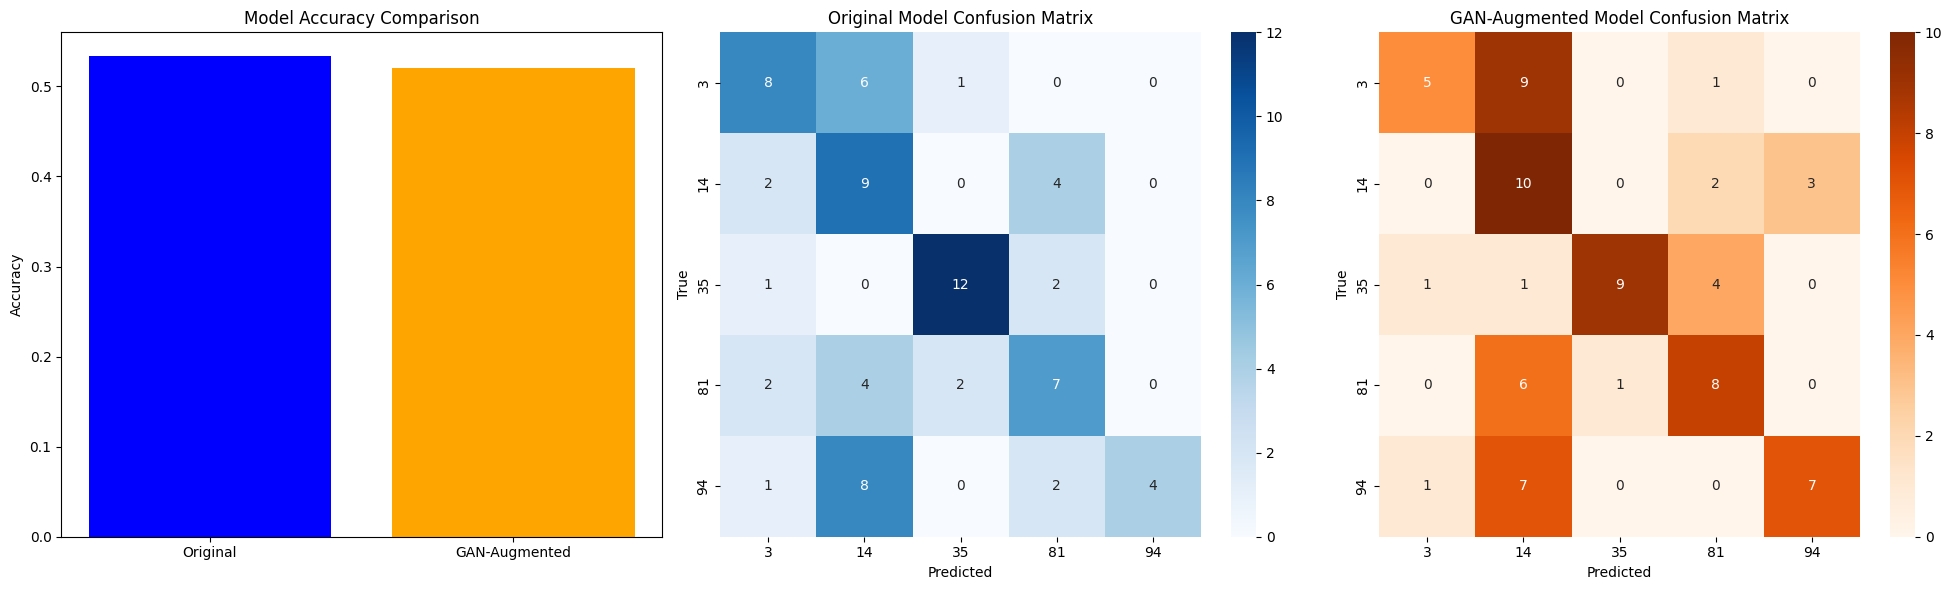

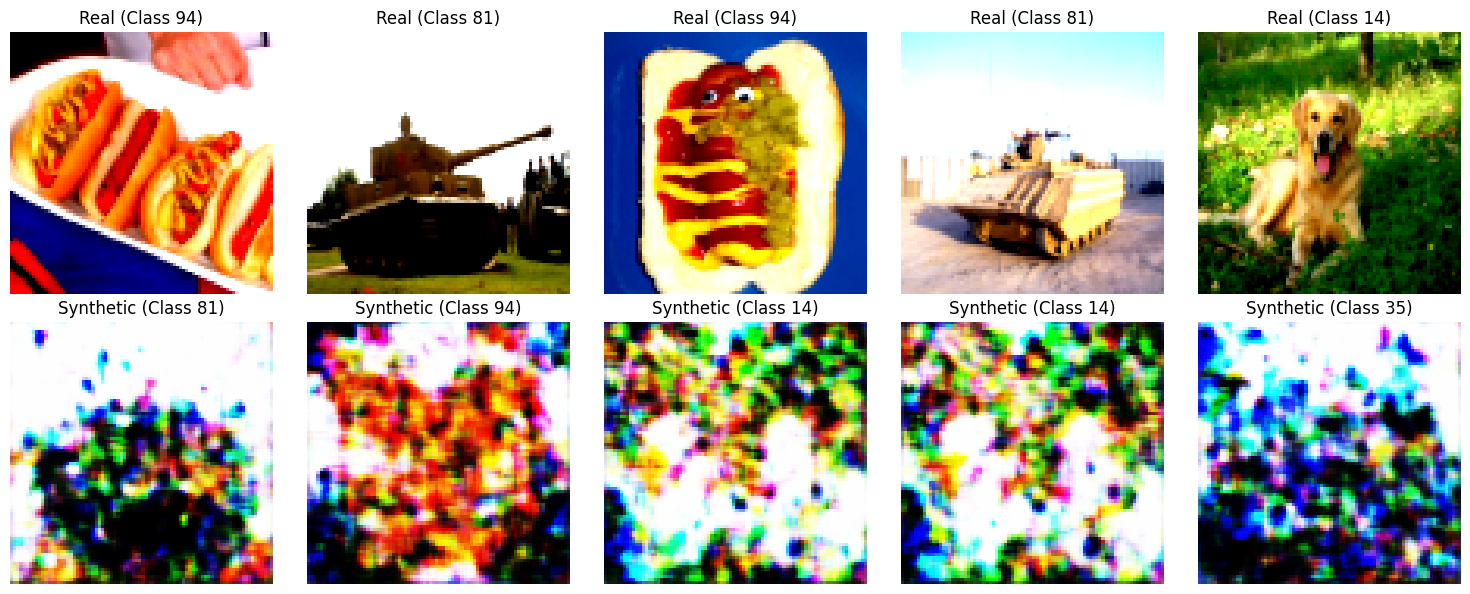

In [63]:
def run_experiment_notebook(dataset="mini-imagenet", n_ways=5, n_shots=5, seed=42, use_wandb=False):
    # Update configuration
    Config.n_ways = n_ways
    Config.n_shots = n_shots
    Config.use_wandb = use_wandb
    
    # Run experiment with cached function
    print(f"Running experiment with: {n_ways}-way {n_shots}-shot")
    try:
        results, _, _ = run_experiment(seed=seed)
        print("\nExperiment completed!")
    except Exception as e:
        print(f"Error during experiment: {str(e)}")
        import traceback
        traceback.print_exc()

# Call with default parameters or customize as needed
run_experiment_notebook()
# Example with custom parameters:
# run_experiment_notebook(n_ways=3, n_shots=10, seed=123)